# 

In [1]:
import torch

import time
import matplotlib.pyplot as plt

import numpy as np

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# 1. Getting started with Pytorch

### Tensors

Pytorch stores data in tensors. These work similarly to `numpy` arrays.
Fore more info, see the [Pytorch tutorial](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)

In [2]:
X = torch.rand(5,2) # creates a random tensor
Y = torch.ones(2,3) # creates a tensor full of ones

Z = X @ Y # matrix multiplication
print(X.shape, Y.shape, Z.shape)

torch.Size([5, 2]) torch.Size([2, 3]) torch.Size([5, 3])


In [3]:
# tensors are indexed as in numpy
print("First element : ", Z[0,0])
print("First column : ", Z[:,0])
print("First row : ", Z[0,:])

First element :  tensor(0.6041)
First column :  tensor([0.6041, 1.2080, 0.5937, 0.7341, 1.1839])
First row :  tensor([0.6041, 0.6041, 0.6041])


## Hardware acceleration

To  optimize computations, it is possible to use accelerators (ex: graphical processing units with CUDA, MPS, MTIA, or XPU). These allow to perform multiple operations in parallel and to gain considerable speedup in operations such as matrix multiplication. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


To perform operations on the accelerator device, one needs to tell Pytorch to move it there.

In [5]:
X = X.to(device)

Let us try to measure this acceleration on multiplication of large matrices. We compare a similar operation, with and without device.

In [6]:
X = torch.rand(10000,10000) # create a big tensor on CPU

In [7]:
start = time.time()
XtX = X.T @ X   # expensive matrix computation
end = time.time()
print("Time needed on CPU : ", end - start)

Time needed on CPU :  17.350683450698853


In [8]:
# now let us move X to accelerator
X = X.to(device)

start = time.time()
XtX = X.T @ X
end = time.time()
print("Time needed on accelerator : ", end - start)

Time needed on accelerator :  0.1408069133758545


## Automatic differentiation

A key feature of Pytorch is that it allows to compute **automatically** the gradient of complicated functions using the chain rule.
Let us demonstrate how this works on the linear regression problem $$f(w) = \frac 12 \|Aw-b\|_2^2.$$



In [9]:
n,d = 10, 5
A = torch.rand(n,d)
b = torch.rand(n)

# we set requires_grad = True so that Pytorch knows that we will need to compute gradients with respect to w
w = torch.randn(d, requires_grad = True)

# least squares loss
loss = 0.5 * ((A @ w - b) ** 2).sum()

loss.backward() # performs backpropagation

grad_w = w.grad # this now contains the gradient of the loss with respect to w

Pytorch represents the process of computing the loss as a **computational graph**. In this graph, the leaves represent variables (such as w) and nodes correspond to elementary operations whose derivative are known (e.g., sums, matrix multiplication, logarithms...).

To compute the gradient with respect to $w$, PyTorch applies the chain rule recursively along this graph, starting from the loss and moving backward toward the variables: this is called **backpropagation**. Note that before performing backpropagation, it is important to compute the loss first.

Let us check that the gradient computed is indeed correct. Compute the gradient analytically and compare with the result returned by Pytorch.

In [10]:

grad_w_manual = A.T @ (A @ w - b) # COMPLETE HERE
torch.norm(grad_w - grad_w_manual)

tensor(0., grad_fn=<LinalgVectorNormBackward0>)

# 2. Loading the dataset

Pytorch has a integrated module for dowloading and managing datasets. Below, we download and load the MNIST digits dataset, separated into train and test data.

In [11]:
MNIST_train = datasets.MNIST(root="data", train=True, download=True, transform=ToTensor())

MNIST_test = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 496kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


In [12]:
X_train = MNIST_train.data.float()
y_train = MNIST_train.targets


X_train.shape, y_train.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [13]:
X_test = MNIST_test.data.float()
y_test = MNIST_test.targets

X_test.shape, y_test.shape

(torch.Size([10000, 28, 28]), torch.Size([10000]))

Let us visualize some images.

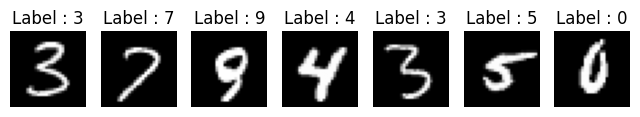

In [14]:
figure = plt.figure(figsize=(8, 8))
n_figs = 7

for i in range(n_figs):
    idx = np.random.randint(X_train.shape[0]) # take one image at random

    figure.add_subplot(1, n_figs, i + 1)
    img, label = X_train[idx], y_train[idx].item()

    plt.title("Label : " + str(label))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap = "gray")

# 3. Building the neural network architecture

We will implement the example used in the Pytorch tutorial which can be found [here](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)

**Defining the neural network class**

Neural networks comprise of layers/modules that perform operations on data.

We define our neural network by subclassing `nn.Module`, and initialize the neural network layers in `__init__`. Every `nn.Module` subclass implements the operations on input data in the forward method.

A neural network is a module itself that consists of other modules (layers). This nested structure allows for building and managing complex architectures easily.

Here, we build a neural network with three fully connected layers and ReLU nonlinearity.

In [15]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        output = self.layers(x)
        return output

We create an instance of `NeuralNetwork`, and move it to the device, and print its structure.

In [16]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [17]:
layer_weight_number = [p.numel() for p in model.parameters()]
print("Number of weights for each parameter : ", layer_weight_number)
print("Total number of weights in the model : ", sum(layer_weight_number))

Number of weights for each parameter :  [50176, 64, 2048, 32, 320, 10]
Total number of weights in the model :  52650


**Applying the model to an image**

Let us apply our model to the first image in our dataset to understand its output.

In [18]:
X0, y0 = X_train[0], y_train[0]

# this make the shape (1,28,28) instead of (28,28)
# indeed, the first dimension the model takes in the input is the batch dimension
X0 = X0.unsqueeze(0)

output = model(X0.to(device))
print(output)

tensor([[ 11.9390,   7.1922,   0.8884,   4.4611,  -7.3947,   3.4681, -10.5035,
           2.2828,  10.7877,  -5.3518]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


The model returns a 10-dimensional vector which encodes the prediction score for each class. To turn this into prediction *probabilities*, we pass it through the softmax function, where

$$[softmax(u)]_i = \frac{e^{u_i}}{\sum_{j=0}^9 e^{u_j}}$$

In [19]:
predicted_probab = nn.Softmax(dim=1)(output)
print(predicted_probab)

tensor([[7.5429e-01, 6.5465e-03, 1.1976e-05, 4.2650e-04, 3.0269e-09, 1.5801e-04,
         1.3516e-10, 4.8293e-05, 2.3852e-01, 2.3348e-08]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)


This vector now represents the probability, according to the model, that the image belongs to each class. The predicted class corresponds to the index with the largest probability.

In [20]:
y0_pred = predicted_probab.argmax(1).item()
print("Predicted class:", y0_pred)
print("True class:", y0.item())

Predicted class: 0
True class: 5


We now proceed to train the model to predict the correct class. To this end, we first define the loss function. For multi-class classification problems, it is common to use the Cross Entropy Loss (a generalization of the logistic loss to multiple classes)

In [21]:
# defining the loss function
loss_fn = nn.CrossEntropyLoss()

###

### 3.1

Each weight from our neural network is a optimization variable that we are going to train. Thus, we are going to train $784*32 + 32*32 + 32*10 = 26432$. We also have to compute bias, for that we can only multiply it by two: $ 26432+10+32+32 = 26506$


# 4 .Training the neural network

We are now going to implement the stochastic gradient method using the Pytorch functionalities.


### Computing gradient and updating weights

First, we need to understand how to compute gradients using auto-differentation

In [22]:
# example of a gradient computation : computing the gradient of the loss on
# one batch

X_batch, y_batch = X_train[:5], y_train[:5]

logits = model(X_batch.to(device))
loss = loss_fn(logits, y_batch.to(device)) # compute loss function on current batch

model.zero_grad()   # clear old gradients (important !)
loss.backward()     # compute gradients by backpropagation

print("The current loss on batch [0:5] is equal to ", loss.item())

# now the gradients for each layer weights are stored inside the model.
for param in model.parameters():
    print(param.grad.shape)

The current loss on batch [0:5] is equal to  8.973873138427734
torch.Size([64, 784])
torch.Size([64])
torch.Size([32, 64])
torch.Size([32])
torch.Size([10, 32])
torch.Size([10])


The next function allows to perform a gradient step to update the model parameters.

In [23]:
@torch.no_grad()
def gradient_step(model, step_size):
    for param in model.parameters():
        param.add_( - step_size * param.grad ) # performing the addition in place

## Implementing SGD

It is now your turn ! Implement the stochastic gradient method using backpropagation, for a given batch size and step size sequence.

In [24]:
def train_loss(model, X, Y):
    # COMPLETE HERE
    with torch.no_grad():
      X_device = X.to(device)
      y_device = Y.to(device)
      logits = model(X_device)
      loss = loss_fn(logits, y_device).item()
    return loss

In [25]:
# computing the accuracy
def accuracy(model, X, Y):
    model.eval()
    with torch.no_grad():
        X_device = X.to(device)
        y_device = Y.to(device)
        logits = model(X_device)
        pred_probab = nn.Softmax(dim=1)(logits)
        y_pred = pred_probab.argmax(1)

        correct_predictions = (y_pred == y_device).type(torch.float).sum().item()
        total_samples = y_device.shape[0]
        acc = correct_predictions / total_samples
    model.train()
    return acc

In [26]:
def SGD(model, gamma, batch_size, N_iterations, decreasing=False, num_epochs=1):
    losses = []
    accuracies = []
    data_size = X_train.shape[0]

    current_data_idx = 0
    epoch = 0

    # initial shuffle
    permutation = torch.randperm(data_size)
    X_shuffled = X_train[permutation]
    y_shuffled = y_train[permutation]

    for i in range(N_iterations):

        # new epoch if we reached the end
        if current_data_idx >= data_size:
            epoch += 1
            if epoch >= num_epochs:
                break

            permutation = torch.randperm(data_size)
            X_shuffled = X_train[permutation]
            y_shuffled = y_train[permutation]
            current_data_idx = 0

        end = min(current_data_idx + batch_size, data_size)

        X_batch = X_shuffled[current_data_idx:end].to(device)
        y_batch = y_shuffled[current_data_idx:end].to(device)

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        model.zero_grad()
        loss.backward()

        gradient_step(model, gamma / X_batch.shape[0])

        current_data_idx = end

        if decreasing and (i > 0) and (i % 100 == 0):
            gamma = gamma / 2

        if (i % 100 == 0) or (i == N_iterations - 1):
            full_train_loss = train_loss(model, X_train, y_train)
            losses.append(full_train_loss)
            acc = accuracy(model, X_train, y_train)
            accuracies.append(acc)

    return losses, accuracies


In [27]:
# do not forget to re-initialize model between runs :
model = NeuralNetwork().to(device)

**Tuning the step size**

Try different values of fixed step size and compare the performance by plotting the train loss.
Some tips :
- you need to compute the train loss on the **full data**. Since this requires iterating over the full dataset, do not do this at each stochastic gradient step, but only once in a while
- if one epoch takes too long, decrease the number of total iterations
- in SGD, the batch should be taken as a random subset of the data points. However, from a computational standpoint, it is much more efficient to pre-shuffle the data and take minibatches sequentially

Step size = 0.0001, batch_size = 10
Step size = 0.0001, batch_size = 50
Step size = 0.0001, batch_size = 100
Step size = 0.001, batch_size = 10
Step size = 0.001, batch_size = 50
Step size = 0.001, batch_size = 100
Step size = 0.01, batch_size = 10
Step size = 0.01, batch_size = 50
Step size = 0.01, batch_size = 100


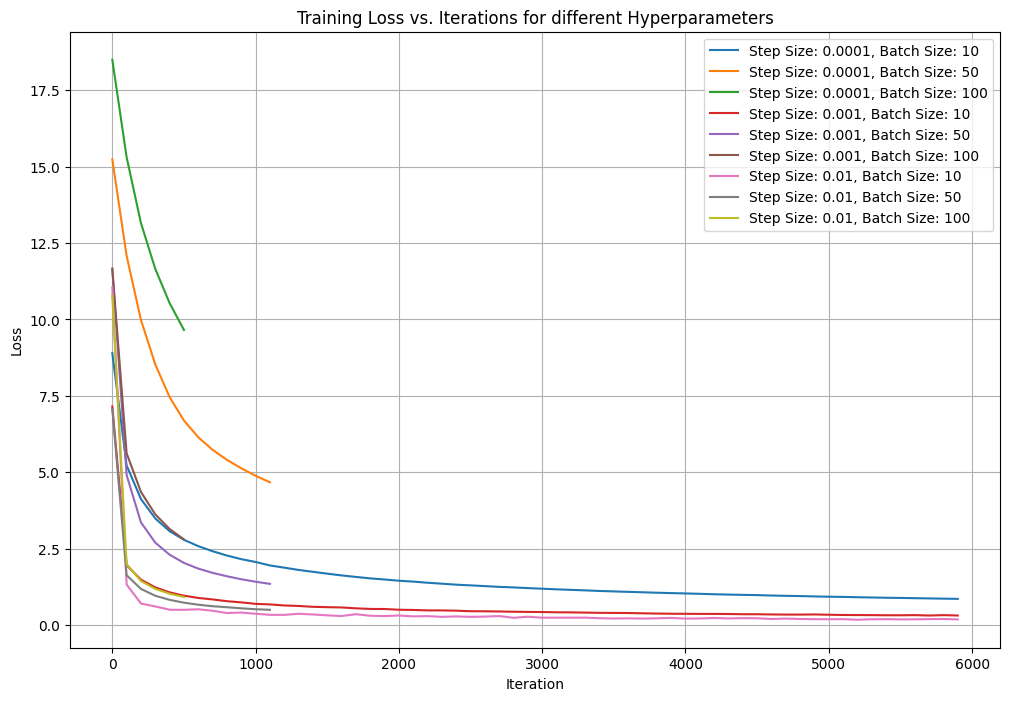

In [28]:
# try different values of step size and plot
steps = [0.0001, 0.001, 0.01]
batches = [10, 50, 100]
N_iterations = 20000
accuracies_fixed = []
test_acc_fix = []

plt.figure(figsize=(12, 8))
plt.title("Training Loss vs. Iterations for different Hyperparameters")
plt.xlabel("Iteration")
plt.ylabel("Loss")

for step in steps:
  for batch in batches:
    print(f"Step size = {step}, batch_size = {batch}")
    # do not forget to re-initialize model between runs for fair comparison
    model = NeuralNetwork().to(device)
    #train and plot results
    losses, acc = SGD(model, step, batch, N_iterations)
    accuracies_fixed.append(acc)
    test_acc_fix.append(accuracy(model,X_test, y_test))
    plt.plot(np.arange(len(losses)) * 100, losses, label=f"Step Size: {step}, Batch Size: {batch}")

plt.legend()
plt.grid(True)
plt.show()

-> Comment

First, it is possible to notice that the curves of higher batch sizes execute less iterations. That happens because one iteration with a high batch size covers a much bigger part of the data set than a iteration with a small batch size. The batch_size = 100, for example, covers the whole data set in 600 iterations only.

Also, the smallest batch size achieved the best result faster than the others. This happened because the model received updates more frequently with a relatively high step size. So we had a faster convergence.

decreasing step size , batch_size = 10
decreasing step size , batch_size = 50
decreasing step size , batch_size = 100


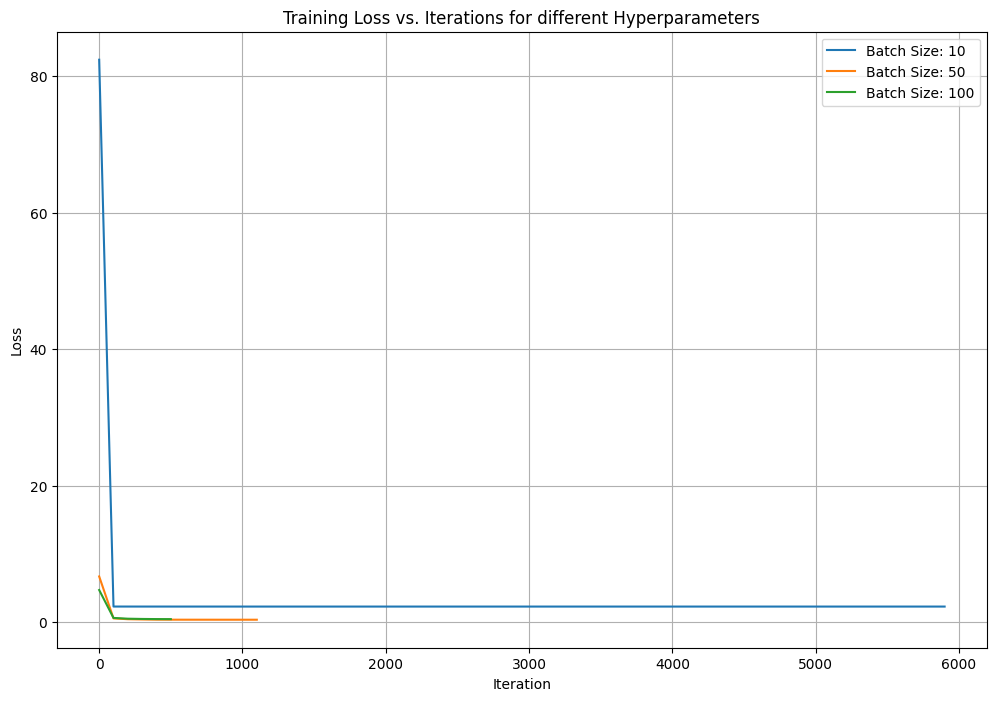

In [29]:
#test decreasing step size
batches = [10, 50, 100]
N_iterations = 10000 # update stepsize each 100 iterations
accuracies_decreasing = []
test_acc_dec = []

plt.figure(figsize=(12, 8))
plt.title("Training Loss vs. Iterations for different Hyperparameters")
plt.xlabel("Iteration")
plt.ylabel("Loss")

# initialize model

for batch in batches:
    model = NeuralNetwork().to(device)
    print(f"decreasing step size , batch_size = {batch}")
    #train and plot results
    losses, acc = SGD(model, 0.1, batch, N_iterations, decreasing=True)
    accuracies_decreasing.append(acc)
    test_acc_dec.append(accuracy(model, X_test, y_test))
    plt.plot(np.arange(len(losses)) * 100, losses, label=f"Batch Size: {batch}")

plt.legend()
plt.grid(True)
plt.show()

### Computing the model accuracy

Examine  how the accuracy evolves during the training.

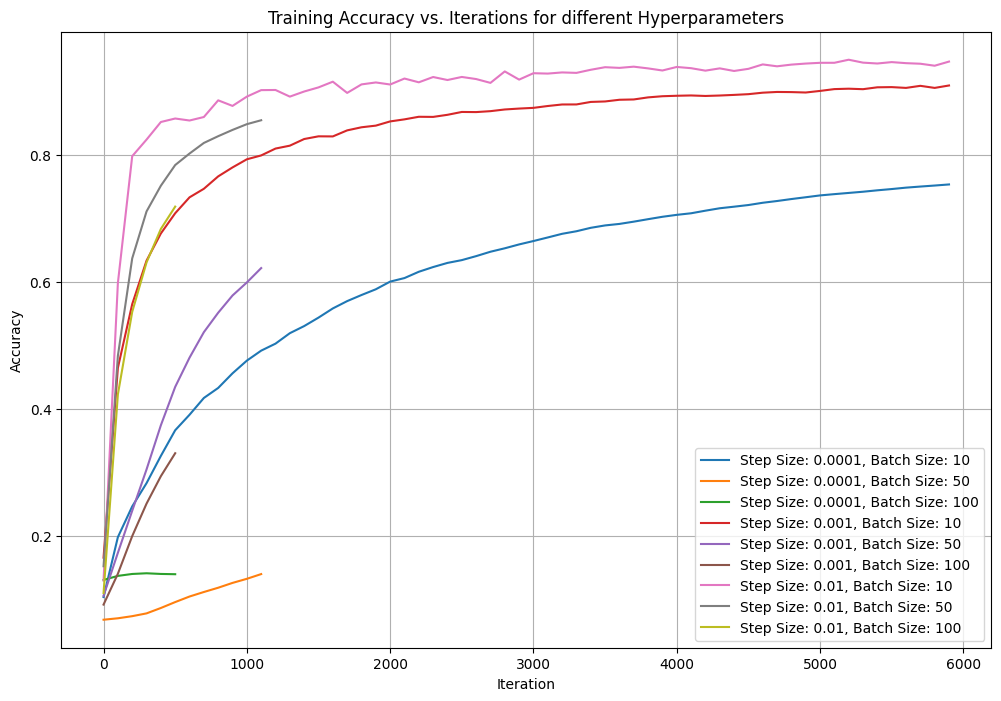

In [30]:
plt.figure(figsize=(12, 8))
plt.title("Training Accuracy vs. Iterations for different Hyperparameters")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")

steps = [0.0001, 0.001, 0.01]
batches = [10, 50, 100]

i = 0
for step in steps:
  for batch in batches:
    accuracies_fixed[i]
    plt.plot(np.arange(len(accuracies_fixed[i])) * 100, accuracies_fixed[i], label=f"Step Size: {step}, Batch Size: {batch}")
    i += 1
plt.legend()
plt.grid(True)
plt.show()


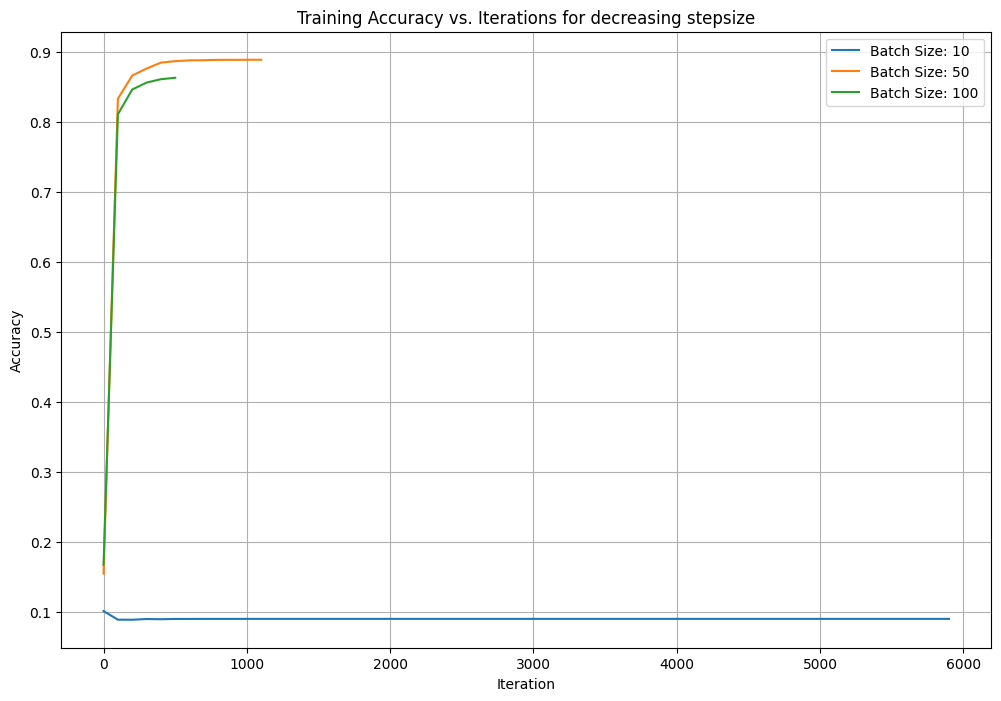

In [31]:
plt.figure(figsize=(12, 8))
plt.title("Training Accuracy vs. Iterations for decreasing stepsize")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")

batches = [10, 50, 100]

i = 0
for batch in batches:
  accuracies_decreasing[i]
  plt.plot(np.arange(len(accuracies_decreasing[i])) * 100, accuracies_decreasing[i], label=f"Batch Size: {batch}")
  i += 1

plt.legend()
plt.grid(True)
plt.show()



To evaluate the performance of your model, you need to compute its accuracy on the test data.

In [33]:
#evaluate models on test
steps = [0.0001, 0.001, 0.01]
batches = [10, 50, 100]

i = 0
for step in steps:
  for batch in batches:
    print(f"Accuracy: {test_acc_fix[i]} | Step Size: {step}, Batch Size: {batch}")
    i += 1


Accuracy: 0.7617 | Step Size: 0.0001, Batch Size: 10
Accuracy: 0.1395 | Step Size: 0.0001, Batch Size: 50
Accuracy: 0.1401 | Step Size: 0.0001, Batch Size: 100
Accuracy: 0.9095 | Step Size: 0.001, Batch Size: 10
Accuracy: 0.6399 | Step Size: 0.001, Batch Size: 50
Accuracy: 0.3772 | Step Size: 0.001, Batch Size: 100
Accuracy: 0.934 | Step Size: 0.01, Batch Size: 10
Accuracy: 0.8607 | Step Size: 0.01, Batch Size: 50
Accuracy: 0.7495 | Step Size: 0.01, Batch Size: 100


In [34]:
i = 0
for batch in batches:
  print(f"acc: {test_acc_dec[i]} |Batch Size: {batch}")
  i += 1


acc: 0.0892 |Batch Size: 10
acc: 0.8887 |Batch Size: 50
acc: 0.8657 |Batch Size: 100


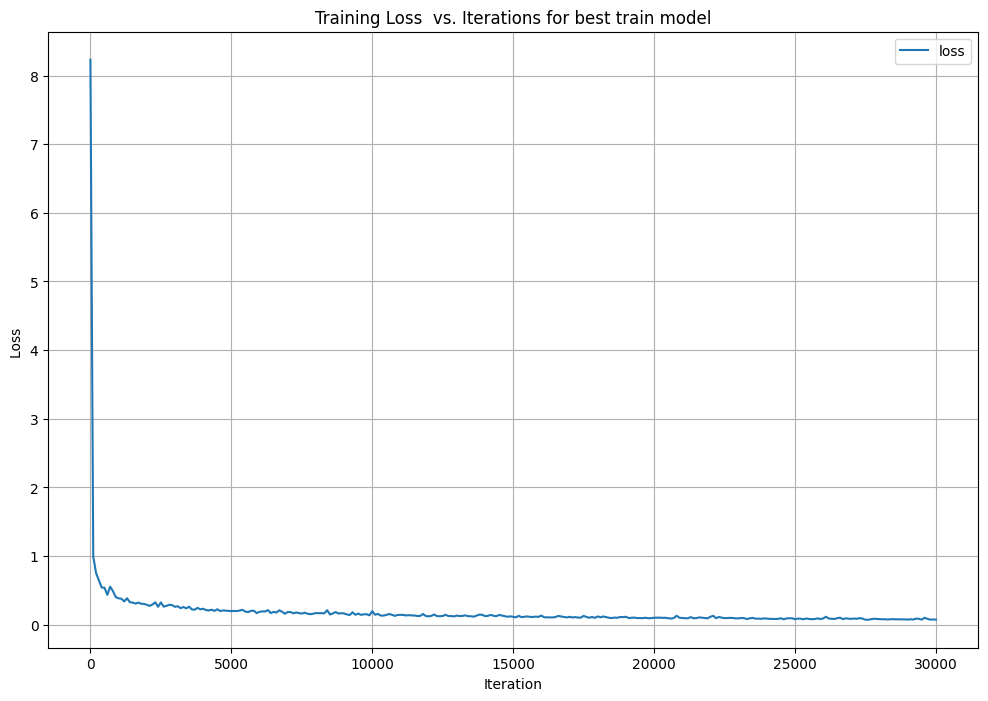

In [38]:
# take best model gamma = 0.01 and batch = 10 and train for 5 epochs

# initialize model
model = NeuralNetwork().to(device)

#train and plot results
final_losses, final_accuracies = SGD(model, gamma=0.01, batch_size=10, N_iterations=30000, decreasing=False, num_epochs=5)

plt.figure(figsize=(12, 8))
plt.title("Training Loss  vs. Iterations for best train model")
plt.xlabel("Iteration")
plt.ylabel("Loss ")
plt.plot(np.arange(len(final_losses)) * 100, final_losses, label=f"loss")
plt.legend()
plt.grid(True)
plt.show()

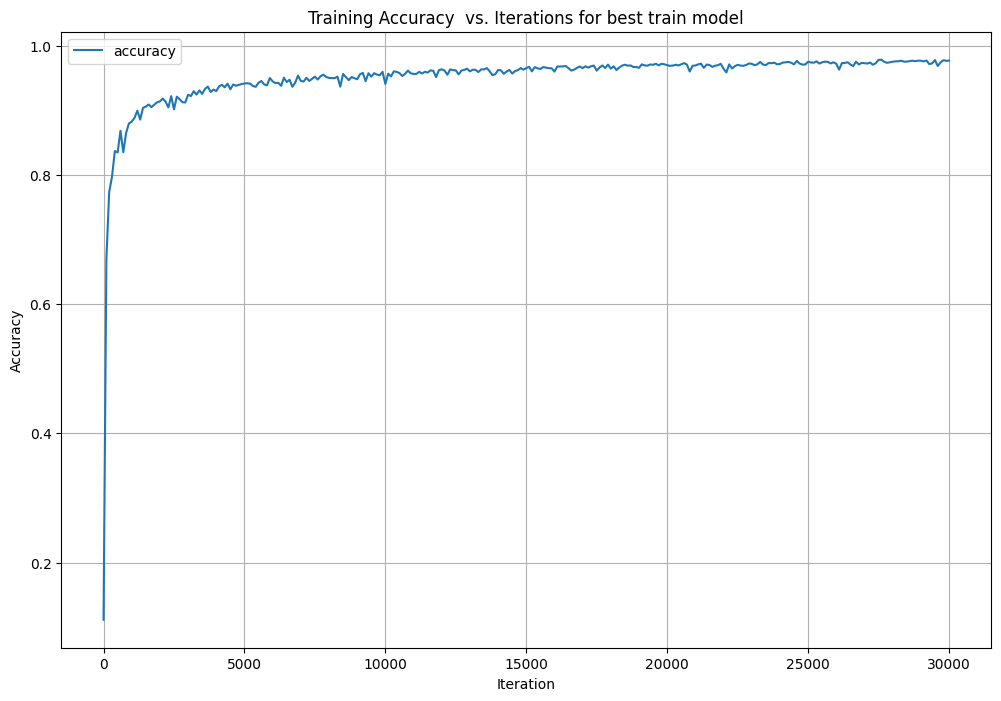

In [39]:

plt.figure(figsize=(12, 8))
plt.title("Training Accuracy  vs. Iterations for best train model")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.plot(np.arange(len(final_accuracies)) * 100, final_accuracies, label=f"accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
final_test_acc = (accuracy(model, X_test, y_test))
print(f"final test acc: {final_test_acc}")

final test acc: 0.9618


-> Comment

We achieved a great accuracy of appromately 96% with the step size = 0.01 and batch = 10. About the training, it is possible to infer that after the loss curve starts becoming flat, it is a good a moment to stop the training. From that moment and on, the training no longer contributes significantly for the metrics.

From our loss plot, we can infer that after the iteration 10000 the curve starts to become flat. The same iteration can be observed as a stop point in the accuracy plot.

## Some concluding remarks

In this TP, you implemented things at a relatively low level so that you understand the mechanics.
In practice, there are some convenient modules that you can use in Pytorch :

- `torch.utils.data.DataLoader` implements the `DataLoader` class to facilitate handling data. It allows to easily preprocess, shuffle and iterate the data.
- `torch.optim` implements ready-to-use optimization algorithms, such as stochastic gradient descent, momentum, Adagrad, Adam...
